# Comparision of ratio or intensities of different tracers
## The units for all the tracers is different so the conversion has been performed within the first part of the code and unit used for the calculation is $s^{-1} cm^{-2} sr^{-1}$ and then the ratios has been calculated 

/var/folders/m3/yz4ltmh13wz1fqwj_nx6m9pc0000gn/T/ipykernel_79427/4161141914.py:29: RuntimeWarning: invalid value encountered in log10
  log_ratio_PAA_HA = np.log10(ratio_PAA_HA)
/var/folders/m3/yz4ltmh13wz1fqwj_nx6m9pc0000gn/T/ipykernel_79427/4161141914.py:31: RuntimeWarning: invalid value encountered in log10
  log_ratio_24_PAA = np.log10(ratio_24_PAA)


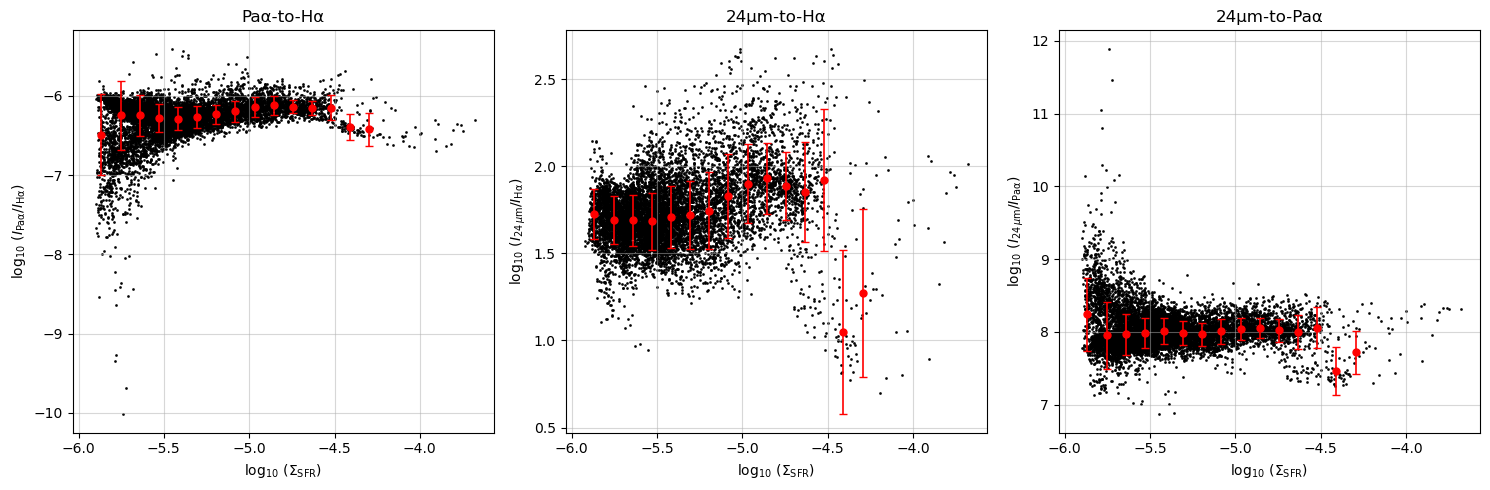

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
c = 3e8  # m/s
lambda_24 = 24e-6      # m
lambda_PAA = 1.875e-6  # m (Paα line)
nu_24 = c / lambda_24
nu_PAA = c / lambda_PAA

# --- Load your data ---
I_Halpha = struct["INT_VAL_HA_SINGS"]       # [erg s^-1 cm^-2 sr^-1]
I_24_MJy = struct["INT_VAL_24UM_HIRES"]     # [MJy sr^-1]
I_PAA_Jy = struct["INT_VAL_F_PAA"]          # [Jy] (assumed Jy/sr)
sigma_SFR =  sigma_SFR                 # [M_sun yr^-1 kpc^-2] Calculated SFR from Leroy+13

# --- Convert all to erg s^-1 cm^-2 sr^-1 ---
# 1 MJy/sr = 1e-17 erg s^-1 cm^-2 Hz^-1 sr^-1
I_24 = I_24_MJy * 1e-17 * nu_24
I_PAA = I_PAA_Jy * 1e-23 * nu_PAA  # Jy → erg s^-1 cm^-2 sr^-1

# --- Compute ratios ---
ratio_PAA_HA = I_PAA / I_Halpha
ratio_24_HA = I_24 / I_Halpha
ratio_24_PAA = I_24 / I_PAA

# --- Prepare log10 values ---
log_SFR = np.log10(SFR_from_sigma)
log_ratio_PAA_HA = np.log10(ratio_PAA_HA)
log_ratio_24_HA = np.log10(ratio_24_HA)
log_ratio_24_PAA = np.log10(ratio_24_PAA)

# --- Function to compute median & 1σ scatter in bins ---
def binned_stats(x, y, nbins=20):
    bins = np.linspace(np.nanmin(x), np.nanmax(x), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    y_median, y_std = [], []
    for i in range(nbins):
        mask = (x >= bins[i]) & (x < bins[i + 1])
        vals = y[mask]
        if np.sum(mask) > 10:
            y_median.append(np.nanmedian(vals))
            y_std.append(np.nanstd(vals))
        else:
            y_median.append(np.nan)
            y_std.append(np.nan)
    return bin_centers, np.array(y_median), np.array(y_std)

# --- Compute medians for each ratio ---
bins_PAA_HA, med_PAA_HA, std_PAA_HA = binned_stats(log_SFR, log_ratio_PAA_HA)
bins_24_HA, med_24_HA, std_24_HA = binned_stats(log_SFR, log_ratio_24_HA)
bins_24_PAA, med_24_PAA, std_24_PAA = binned_stats(log_SFR, log_ratio_24_PAA)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# Common style for scatter
scatter_kw = dict(s=1, color='k', alpha=0.9)
error_kw = dict(fmt='o', color='red', ecolor='red', elinewidth=1.2, capsize=3, markersize=5)

# (a) Paα-to-Hα
axes[0].scatter(log_SFR, log_ratio_PAA_HA, **scatter_kw)
axes[0].errorbar(bins_PAA_HA, med_PAA_HA, yerr=std_PAA_HA, **error_kw)
axes[0].set_ylabel(r'$\log_{10}\, (I_{\mathrm{Pa\alpha}} / I_{\mathrm{H\alpha}})$')
axes[0].set_xlabel(r'$\log_{10}\,(\Sigma_{\mathrm{SFR}})$')
axes[0].set_title('Paα-to-Hα')
axes[0].grid(True, alpha = 0.5)

# (b) 24μm-to-Hα
axes[1].scatter(log_SFR, log_ratio_24_HA, **scatter_kw)
axes[1].errorbar(bins_24_HA, med_24_HA, yerr=std_24_HA, **error_kw)
axes[1].set_ylabel(r'$\log_{10}\, (I_{24\,\mu\mathrm{m}} / I_{\mathrm{H\alpha}})$')
axes[1].set_xlabel(r'$\log_{10}\,(\Sigma_{\mathrm{SFR}})$')
axes[1].set_title('24μm-to-Hα')
axes[1].grid(True, alpha = 0.5)

# (c) 24μm-to-Paα
axes[2].scatter(log_SFR, log_ratio_24_PAA, **scatter_kw)
axes[2].errorbar(bins_24_PAA, med_24_PAA, yerr=std_24_PAA, **error_kw)
axes[2].set_ylabel(r'$\log_{10}\, (I_{24\,\mu\mathrm{m}} / I_{\mathrm{Pa\alpha}})$')
axes[2].set_xlabel(r'$\log_{10}\,(\Sigma_{\mathrm{SFR}})$')
axes[2].set_title('24μm-to-Paα')
axes[2].grid(True, alpha = 0.5)

plt.tight_layout()
plt.show()


## Implementation to all the tracers 

/var/folders/m3/yz4ltmh13wz1fqwj_nx6m9pc0000gn/T/ipykernel_79427/1291322302.py:94: RuntimeWarning: invalid value encountered in log10
  ratios[key] = np.log10(I_dict[num] / I_dict[den])


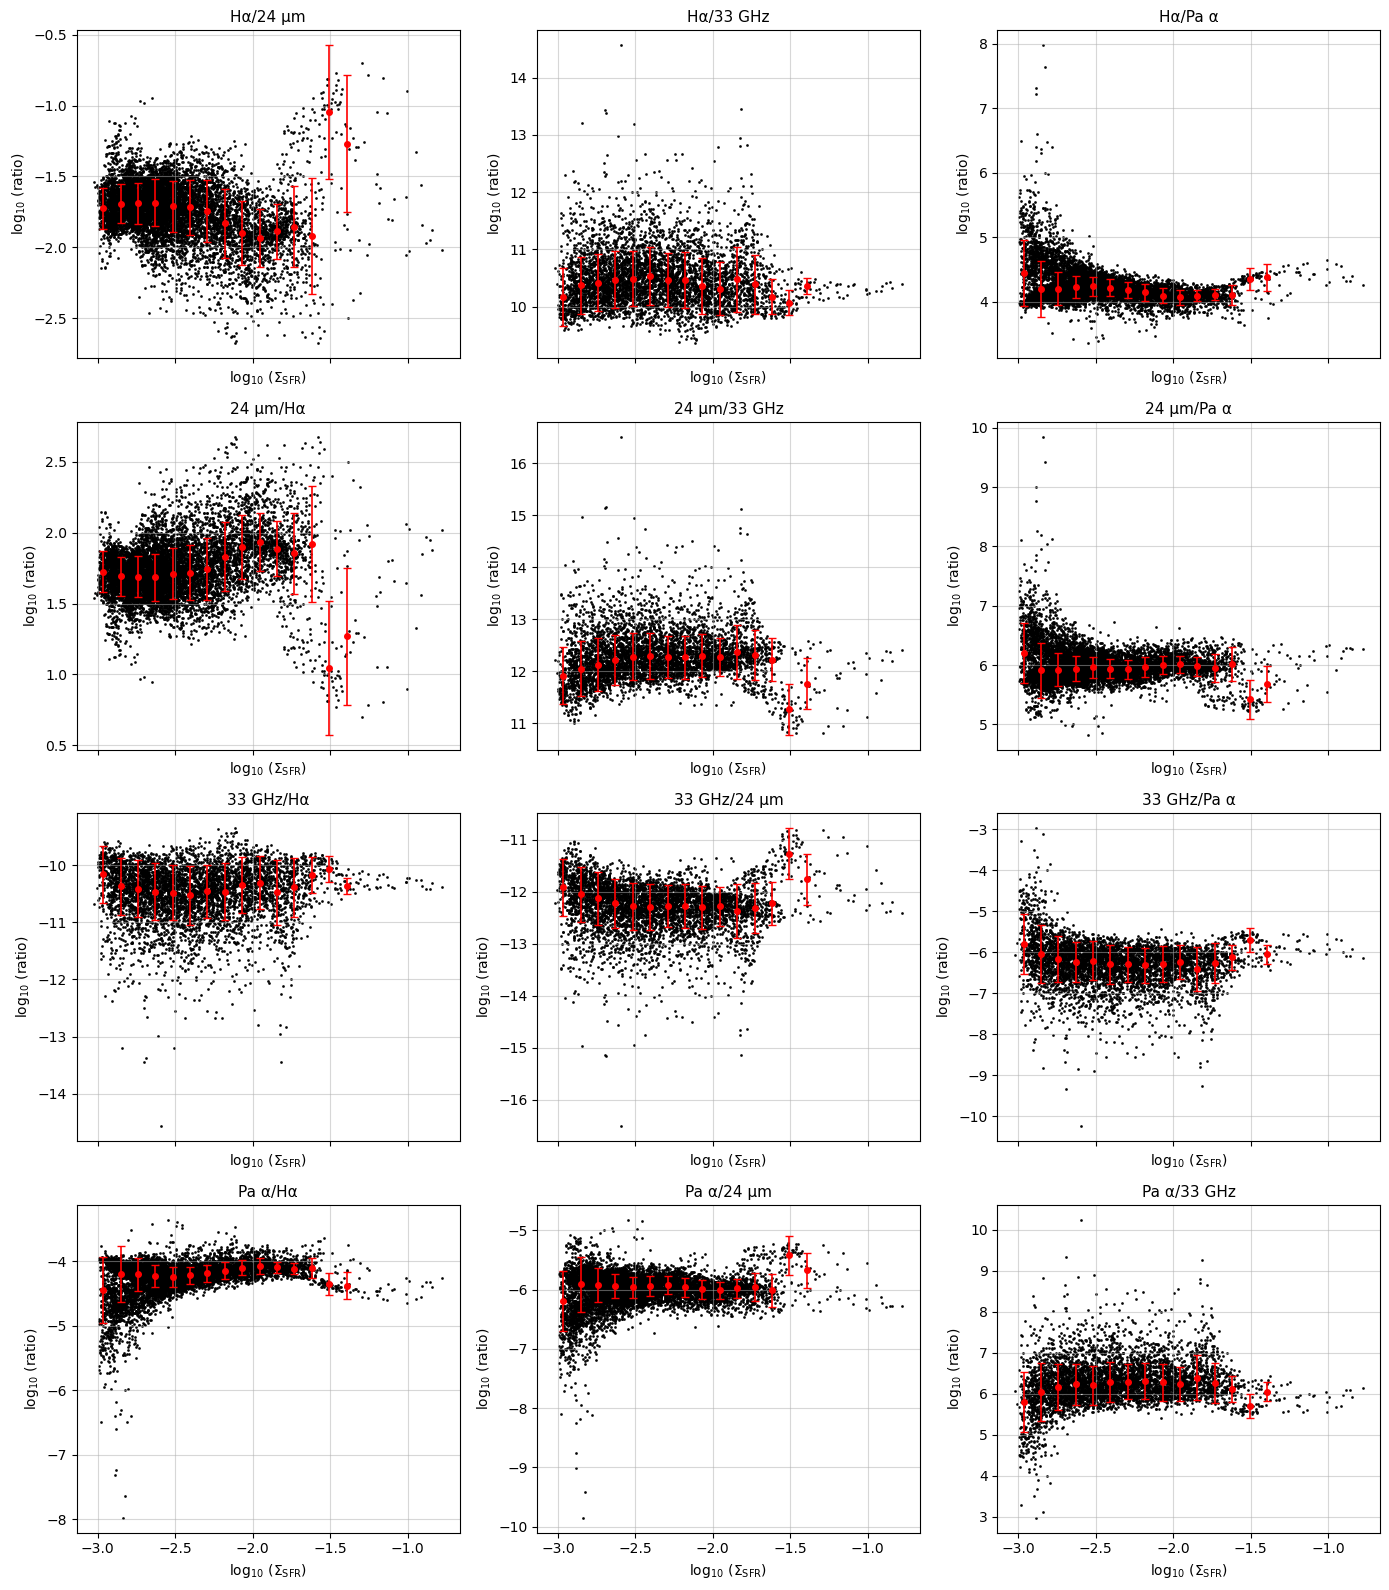

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Constants
# -------------------------------
c = 2.99792458e8  # m/s
kpc_to_cm = 3.086e21
mpc_to_cm = 3.086e24
jy_to_ergs = 1e-23  # erg s^-1 cm^-2 Hz^-1

# Galaxy parameters
d = 8.58  # Mpc
D_cm = d * mpc_to_cm  # cm

# Wavelengths and frequencies
lambda_24 = 24e-6
lambda_PAA = 1.875e-6
nu_24 = c / lambda_24
nu_PAA = c / lambda_PAA
nu_33GHz = 33e9

# ---------------------------------
# Pixel angular sampling (radians)
# ---------------------------------
pix_size_PAA = 1.11e-5  # JWST
pix_size_VLA = 5.55e-5  # VLA

# Projected pixel area on the sky (square grid)
area_pix_PAA_cm2 = (D_cm * pix_size_PAA)**2
area_pix_PAA_kpc2 = area_pix_PAA_cm2 / (kpc_to_cm**2)
area_pix_VLA_cm2 = (D_cm * pix_size_VLA)**2
area_pix_VLA_kpc2 = area_pix_VLA_cm2 / (kpc_to_cm**2)

# -------------------------------
# Load data (replace struct[...] with your arrays)
# -------------------------------
I_Halpha = struct["INT_VAL_HA_SINGS"]       # erg s^-1 cm^-2 sr^-1
I_24_MJy = struct["INT_VAL_24UM_HIRES"]     # MJy sr^-1
I_PAA_Jy = struct["INT_VAL_F_PAA"]          # Jy / kpc^2
I_33GHz_Jy = struct["INT_VAL_VLA33GHZ"]     # Jy / kpc^2
sigma_SFR = sigma_SFR                       # M☉ yr^-1 kpc^-2

# -------------------------------
# Convert all to erg s^-1 cm^-2 sr^-1
# -------------------------------
# 24 μm
I_24 = I_24_MJy * 1e-17 * nu_24

# Paα and 33GHz: Jy/kpc² → Jy/sr → erg s^-1 cm^-2 sr^-1
I_PAA = I_PAA_Jy * (1 / area_pix_PAA_kpc2) * jy_to_ergs * nu_PAA
I_33GHz = I_33GHz_Jy * (1 / area_pix_VLA_kpc2) * jy_to_ergs * nu_33GHz

# Dictionary of all intensities
I_dict = {
    "Hα": I_Halpha,
    "24 µm": I_24,
    "33 GHz": I_33GHz,
    "Pa α": I_PAA
}

# -------------------------------
# Log SFR for x-axis
# -------------------------------
log_SFR = np.log10(sigma_SFR)

# -------------------------------
# Binned stats function
# -------------------------------
def binned_stats(x, y, nbins=20):
    bins = np.linspace(np.nanmin(x), np.nanmax(x), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    y_median, y_std = [], []
    for i in range(nbins):
        mask = (x >= bins[i]) & (x < bins[i + 1])
        vals = y[mask]
        if np.sum(mask) > 10:
            y_median.append(np.nanmedian(vals))
            y_std.append(np.nanstd(vals))
        else:
            y_median.append(np.nan)
            y_std.append(np.nan)
    return bin_centers, np.array(y_median), np.array(y_std)

# -------------------------------
# Prepare ratios for all unique pairs
# -------------------------------
bands = list(I_dict.keys())
ratios = {}
for i, num in enumerate(bands):
    for j, den in enumerate(bands):
        if i != j:
            key = f"{num}/{den}"
            ratios[key] = np.log10(I_dict[num] / I_dict[den])

# Compute medians
binned = {key: binned_stats(log_SFR, val) for key, val in ratios.items()}

# -------------------------------
# Plot 4×3 grid
# -------------------------------
fig, axes = plt.subplots(4, 3, figsize=(14, 16), sharex=True)
scatter_kw = dict(s=1, color='k', alpha=0.9)
error_kw = dict(fmt='o', color='red', ecolor='red', elinewidth=1.2, capsize=3, markersize=4)

for row_i, num in enumerate(bands):
    col = 0
    for den in bands:
        if num == den:
            continue
        key = f"{num}/{den}"
        ax = axes[row_i, col]
        y = ratios[key]
        ax.scatter(log_SFR, y, **scatter_kw)
        bins, med, std = binned[key]
        ax.errorbar(bins, med, yerr=std, **error_kw)
        ax.set_title(key, fontsize=11)
        ax.set_xlabel(r'$\log_{10}\,(\Sigma_{\mathrm{SFR}})$')
        ax.set_ylabel(r'$\log_{10}\,(\mathrm{ratio})$')
        ax.grid(True, alpha=0.5)
        col += 1

plt.tight_layout()
plt.show()


/var/folders/m3/yz4ltmh13wz1fqwj_nx6m9pc0000gn/T/ipykernel_79427/4072563297.py:92: RuntimeWarning: invalid value encountered in log10
  ratios[key] = np.log10(I_dict[num] / I_dict[den])


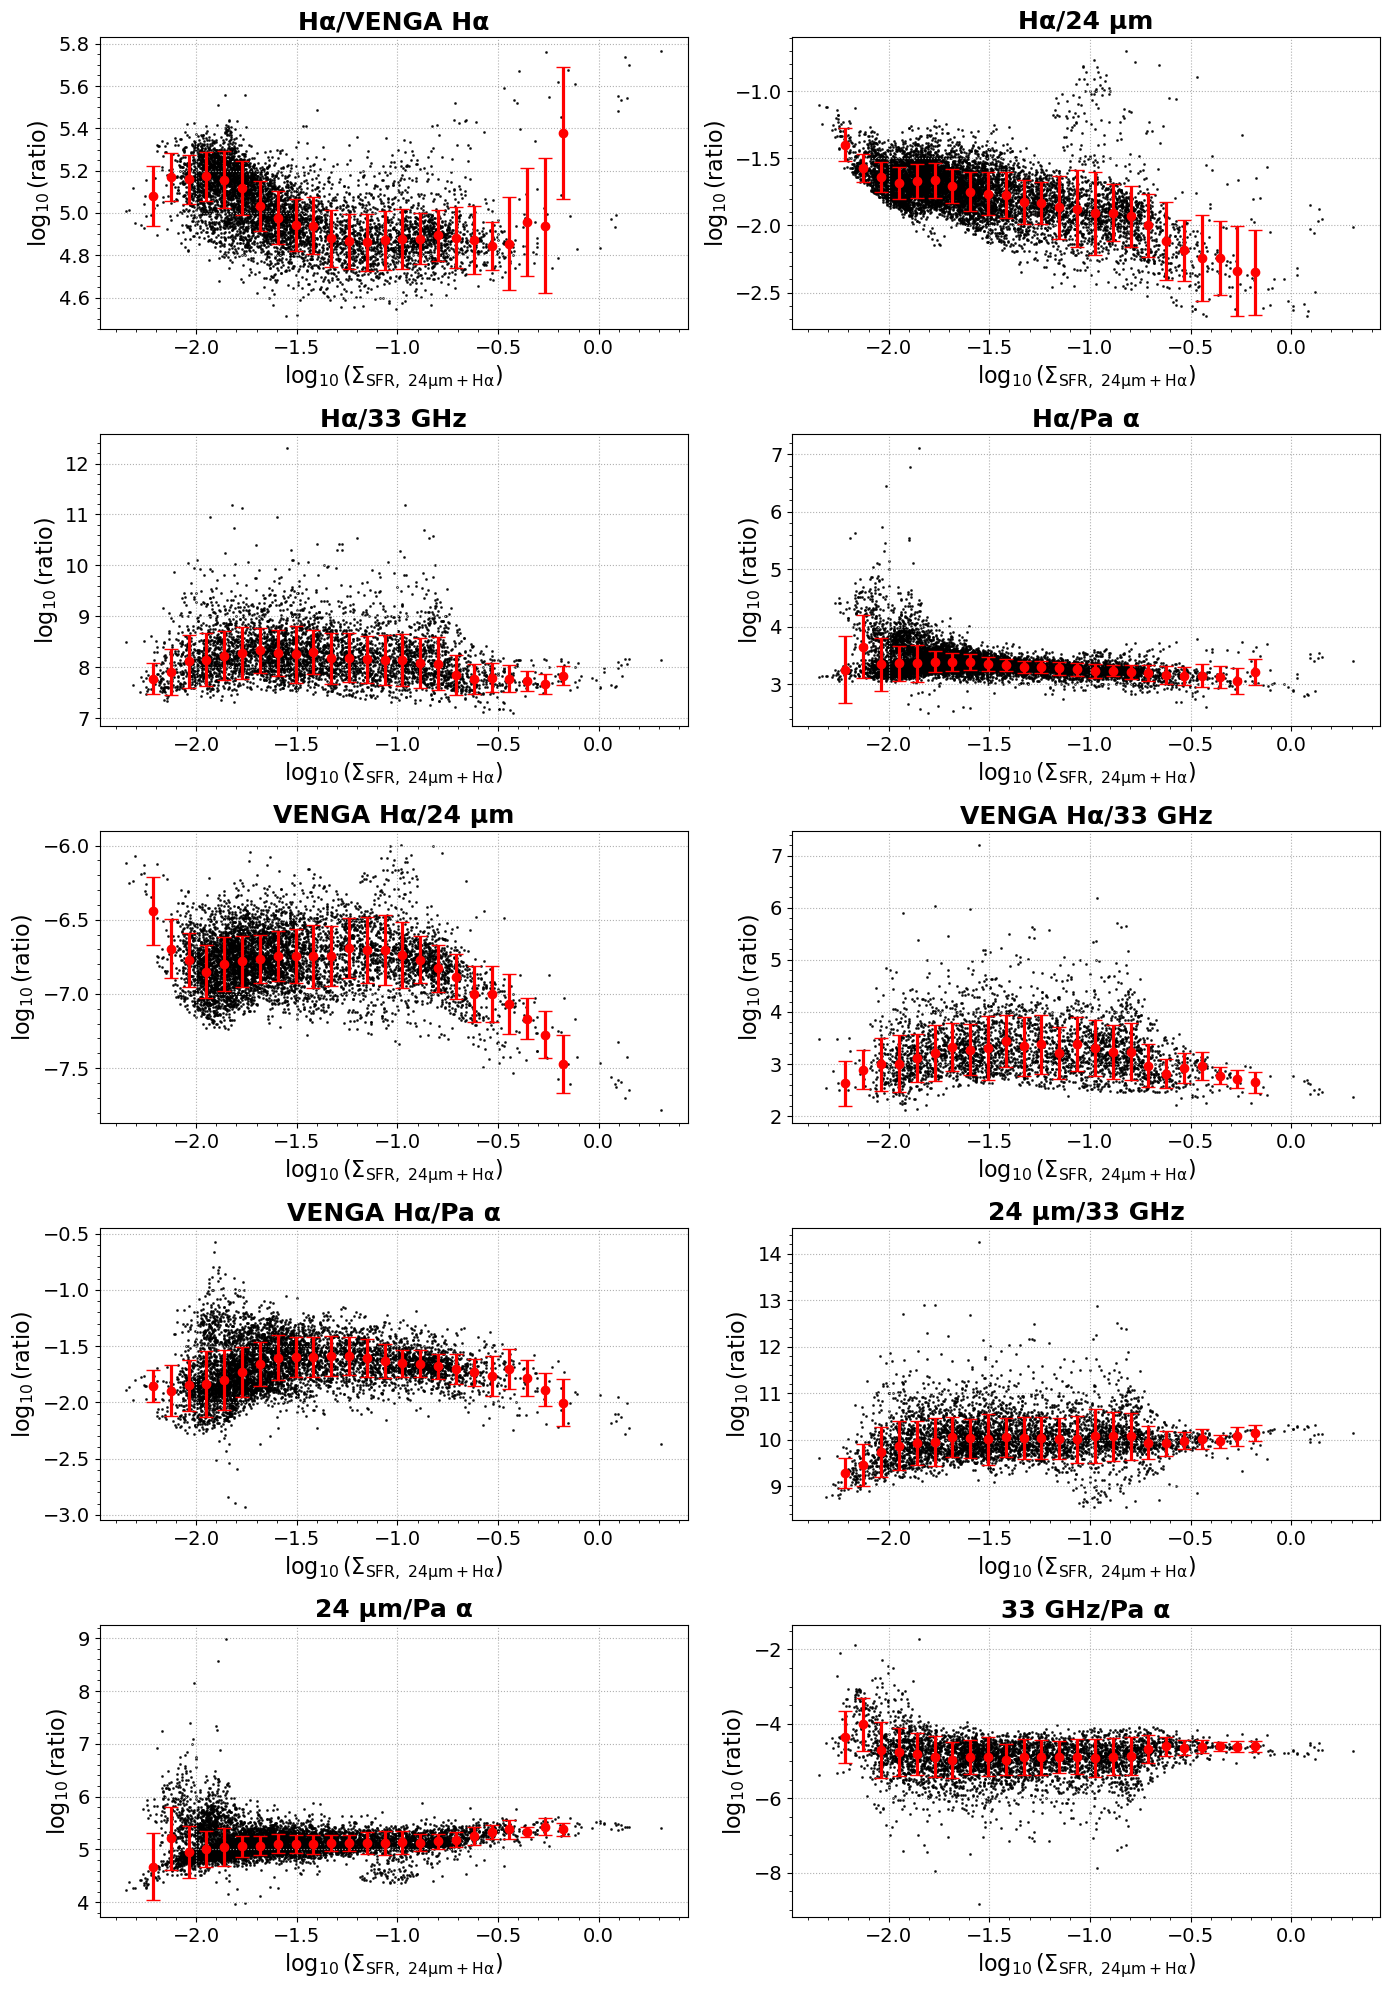

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Constants
# -------------------------------
c = 2.99792458e8  # m/s
kpc_to_cm = 3.086e21
mpc_to_cm = 3.086e24
jy_to_ergs = 1e-23  # erg s^-1 cm^-2 Hz^-1

# Galaxy parameters
d = 8.58  # Mpc
D_cm = d * mpc_to_cm  # cm

# Wavelengths and frequencies
lambda_24 = 24e-6
lambda_PAA = 1.875e-6
nu_24 = c / lambda_24
nu_PAA = c / lambda_PAA
nu_33GHz = 33e9

# Pixel area
area_pix_cm2 = 1.1958222905827292e40
area_pix_kpc2 = area_pix_cm2 / (kpc_to_cm**2)

# -------------------------------
# Load data
# -------------------------------
I_Halpha = struct["INT_VAL_HA_SINGS"]
I_24_MJy = struct["INT_VAL_24UM_HIRES"]
I_PAA_Jy = struct["INT_VAL_F_PAA"]
I_33GHz_Jy = struct["INT_VAL_VLA33GHZ"]
flux_map_VENGA = struct["INT_VAL_VENGA_HA"]
sigma_SFR = uc_sfr

# -------------------------------
# Unit conversions
# -------------------------------

I_24 = I_24_MJy * 1e-17 * nu_24

I_PAA = I_PAA_Jy * (1 / area_pix_kpc2) * jy_to_ergs * nu_PAA

I_33GHz = I_33GHz_Jy * (1 / area_pix_kpc2) * jy_to_ergs * nu_33GHz

I_VENGA = flux_map_VENGA * (1 / area_pix_kpc2)

# -------------------------------
# Dictionary of all intensities
# -------------------------------
I_dict = {
    "Hα": I_Halpha,
    "VENGA Hα": I_VENGA,
    "24 µm": I_24,
    "33 GHz": I_33GHz,
    "Pa α": I_PAA
}

bands = list(I_dict.keys())
log_SFR = np.log10(sigma_SFR)

# -------------------------------
# Binned stats helper
# -------------------------------
def binned_stats(x, y, nbins=30):
    bins = np.linspace(np.nanmin(x), np.nanmax(x), nbins+1)
    centers = 0.5*(bins[:-1] + bins[1:])
    med, std = [], []
    for i in range(nbins):
        m = (x >= bins[i]) & (x < bins[i+1])
        vals = y[m]
        if vals.size > 10:
            med.append(np.nanmedian(vals))
            std.append(np.nanstd(vals))
        else:
            med.append(np.nan)
            std.append(np.nan)
    return centers, np.array(med), np.array(std)

# -------------------------------
# Compute ONLY UNIQUE (i < j) ratios
# -------------------------------
ratio_keys = []
ratios = {}

for i in range(len(bands)):
    for j in range(i+1, len(bands)):  # ensures unique unordered pairs
        num = bands[i]
        den = bands[j]
        key = f"{num}/{den}"
        ratios[key] = np.log10(I_dict[num] / I_dict[den])
        ratio_keys.append(key)

# Precompute binned stats
binned = {key: binned_stats(log_SFR, val) for key, val in ratios.items()}

# -------------------------------
# Plot: 5 rows × 2 columns = 10 unique ratios
# -------------------------------
fig, axes = plt.subplots(5, 2, figsize=(14, 20), sharex=True)
axes = axes.flatten()

scatter_kw = dict(s=1, color='k', alpha=0.8)
error_kw = dict(fmt='o', color='red', ecolor='red', elinewidth=2.3,
                capsize=5, markersize=6)

for ax, key in zip(axes, ratio_keys):

    y = ratios[key]
    bins, med, std = binned[key]

    ax.scatter(log_SFR, y, **scatter_kw)
    ax.errorbar(bins, med, yerr=std, **error_kw)

    ax.set_title(key, fontsize=18, fontweight='bold')
    ax.set_xlabel(r'$\log_{10}(\Sigma_{\rm SFR,\ 24\mu m + H\alpha})$', fontsize=16, fontweight='bold')

    ax.set_ylabel(r'$\log_{10}(\mathrm{ratio})$', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=1, linestyle=':')
    ax.minorticks_on()

    ax.tick_params(axis="x", labelbottom=True, labelsize=14)
    ax.tick_params(axis="y", labelleft=True, labelsize=14)

plt.tight_layout()
plt.show()

## Median emission ratio plot for all the cases of $\Sigma_{SFR}$ 

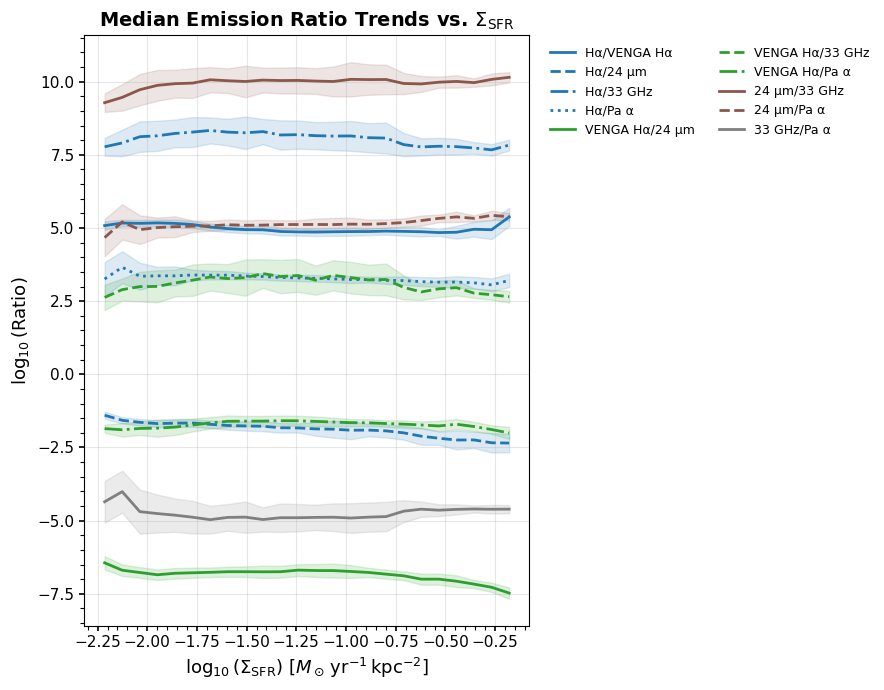

In [42]:
# ==========================================================
# Combined summary plot: median ratio trends vs Σ_SFR
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 7))

# Unique numerators (groups)
numerators = list(I_dict.keys())  # ["Hα", "VENGA Hα", "24 µm", "33 GHz", "Pa α"]

# Give each numerator a color
colors = plt.cm.tab10(np.linspace(0, 1, len(numerators)))

# Line styles to help separate ratios within each group
linestyles = ['-', '--', '-.', ':']

for color, num in zip(colors, numerators):

    # Find all ratios where this band is the numerator
    group_keys = [key for key in binned.keys() if key.startswith(num + "/")]

    for ls, key in zip(linestyles, group_keys):
        bins, med, std = binned[key]

        # Skip invalid rows
        if np.all(np.isnan(med)):
            continue

        # Plot median trend
        plt.plot(bins, med, ls=ls, lw=2, color=color, label=key)

        # Plot ±1σ shaded region
        plt.fill_between(bins, med - std, med + std, color=color, alpha=0.15)

# Axis labels
plt.xlabel(r'$\log_{10}(\Sigma_{\mathrm{SFR}})\ [M_\odot\,\mathrm{yr^{-1}\,kpc^{-2}}]$', fontsize=13)
plt.ylabel(r'$\log_{10}(\mathrm{Ratio})$', fontsize=13)
plt.title(r'Median Emission Ratio Trends vs. $\Sigma_{\mathrm{SFR}}$', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', labelsize=11, width=1.2)
plt.tick_params(axis='both', which='minor', length=3, width=0.8)

# Legend outside the plot
plt.legend(frameon=False, fontsize=9, ncol=2,
           loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


# Comparision of $\Sigma_{SFR}$ with respect to each other with extinction calculated for all the points using Balmer correction from Venga data 

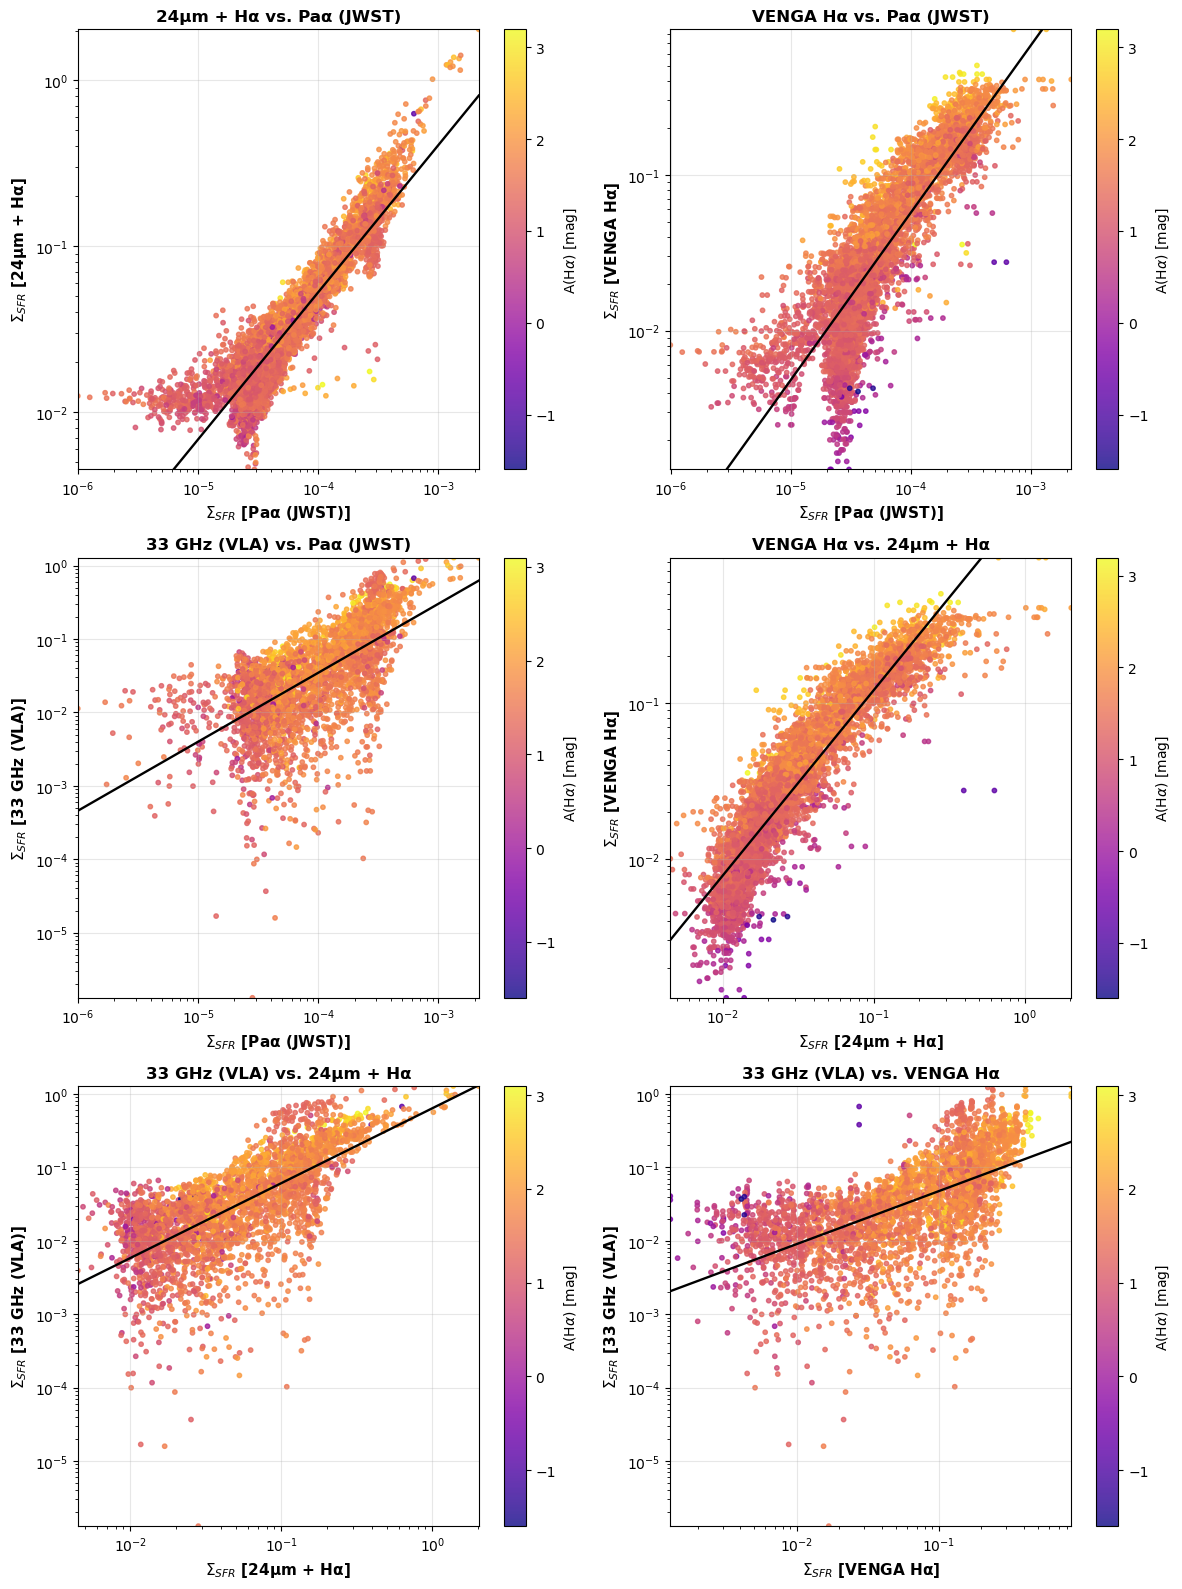

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# --- Extinction from Balmer Decrement ---
flux_map_Ha = struct["INT_VAL_VENGA_HA"]  # erg/s/cm^2/kpc^2
flux_map_Hb = struct["INT_VAL_VENGA_HB"]  # erg/s/cm^2/kpc^2

# Avoid divide-by-zero and log of negative
ratio = np.where((flux_map_Ha > 0) & (flux_map_Hb > 0), flux_map_Ha / flux_map_Hb, np.nan)
A_Halpha = 5.91 * np.log10(ratio / 2.86)

sfr_jwst = SFR_array
sfr_sofia = uc_sfr
sfr_vla = sigma_sfr_vla
sfr_venga = sigma_sfr_venga_extinction_corr

# --- Tracer labels and values ---
tracers = [
    ("Paα (JWST)", sfr_jwst),
    ("24μm + Hα", sfr_sofia),
    ("VENGA Hα", sfr_venga),
    ("33 GHz (VLA)", sfr_vla),
]

# --- Pairwise combinations ---
pairs = [
    (0, 1),  # JWST vs SOFIA
    (0, 2),  # JWST vs VENGA
    (0, 3),  # JWST vs VLA
    (1, 2),  # SOFIA vs VENGA
    (1, 3),  # SOFIA vs VLA
    (2, 3),  # VENGA vs VLA
]

# --- Plotting grid ---
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for ax, (i, j) in zip(axes, pairs):
    label_x, x = tracers[i]
    label_y, y = tracers[j]

    # Valid pixels
    mask = (
        np.isfinite(x) & np.isfinite(y) & np.isfinite(A_Halpha) &
        (x > 0) & (y > 0)
    )

    x_valid = x[mask]
    y_valid = y[mask]
    A_valid = A_Halpha[mask]

    # Scatter plot
    sc = ax.scatter(x_valid, y_valid, c=A_valid,
                    cmap='plasma', s=10, alpha=0.8)

    # ---------------------------------------------------
    # Best-fit line (log–log)
    # ---------------------------------------------------
    logx = np.log10(x_valid)
    logy = np.log10(y_valid)

    m, b = np.polyfit(logx, logy, 1)

    # Smooth fit curve
    fit_x_log = np.linspace(logx.min(), logx.max(), 200)
    fit_y_log = m * fit_x_log + b
    ax.plot(10**fit_x_log, 10**fit_y_log, color='black', linewidth=1.7,
            label=f"log y = {m:.2f} log x + {b:.2f}")

    #ax.legend(fontsize=9)

    # ---------------------------------------------------
    # Axes limits = best bounds from data
    # ---------------------------------------------------
    ax.set_xlim(x_valid.min(), x_valid.max())
    ax.set_ylim(y_valid.min(), y_valid.max())

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(f"$\Sigma_{{SFR}}$ [{label_x}]", fontsize=11, fontweight='bold')
    ax.set_ylabel(f"$\Sigma_{{SFR}}$ [{label_y}]", fontsize=11, fontweight='bold')
    ax.set_title(f"{label_y} vs. {label_x}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    cb = plt.colorbar(sc, ax=ax)
    cb.set_label(r"A(H$\alpha$) [mag]", fontsize=10)




plt.tight_layout()
plt.show()


# Kernal density plots for comparision of $\Sigma_{SFR}$ the plot also features the best fit line and 1:1 line 

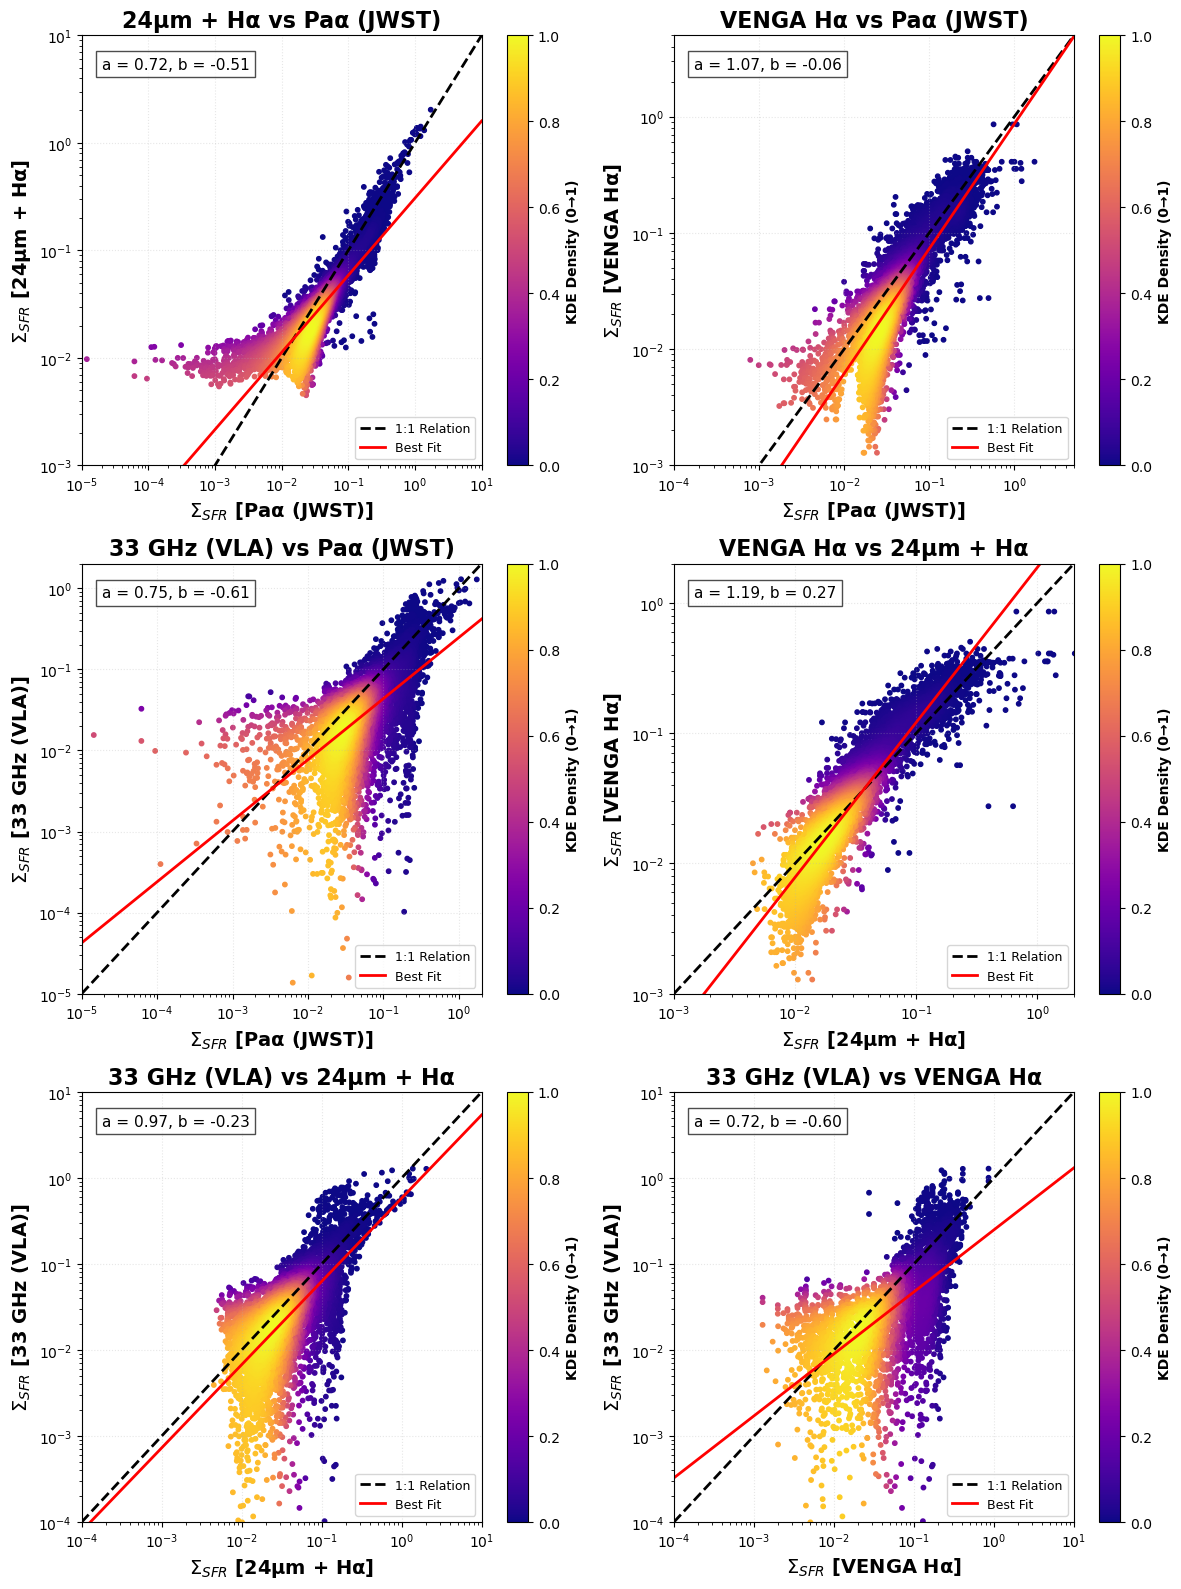

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- Extinction from Balmer Decrement ---
flux_map_Ha = struct["INT_VAL_VENGA_HA"]
flux_map_Hb = struct["INT_VAL_VENGA_HB"]

ratio = np.where((flux_map_Ha > 0) & (flux_map_Hb > 0), flux_map_Ha / flux_map_Hb, np.nan)
A_Halpha = 5.91 * np.log10(ratio / 2.86)

# --- SFR arrays ---
sfr_jwst  = SFR_array                         # Paα (JWST)
sfr_sofia = uc_sfr                            # 24μm + Hα (SOFIA)
sfr_vla   = sigma_sfr_vla                     # 33 GHz (VLA)
sfr_venga = sigma_sfr_venga_extinction_corr   # VENGA Hα (extinction corrected)

# --- Tracer labels & values ---
tracers = [
    ("Paα (JWST)",        sig_SFR_kpc2),
    ("24μm + Hα", sfr_sofia),
    ("VENGA Hα",          sfr_venga),
    ("33 GHz (VLA)",      sfr_vla),
]

# --- Pairwise combinations ---
pairs = [
    (0, 1),
    (0, 2),
    (0, 3),
    (1, 2),
    (1, 3),
    (2, 3),
]

# --- Manual axis limits for each panel ---
x_limits = {
    (0,1): (1e-5, 1e1),
    (0,2): (1e-4, 5e0),
    (0,3): (1e-5, 2e0),
    (1,2): (1e-3, 2e0),
    (1,3): (1e-4, 1e1),
    (2,3): (1e-4, 1e1)
}

y_limits = {
    (0,1): (1e-3, 1e1),
    (0,2): (1e-3, 5e0),
    (0,3): (1e-5, 2e0),
    (1,2): (1e-3, 2e0),
    (1,3): (1e-4, 1e1),
    (2,3): (1e-4, 1e1)
}

# --- Plot grid ---
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for ax, (i, j) in zip(axes, pairs):

    label_x, x = tracers[i]
    label_y, y = tracers[j]

    mask = (np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0))
    x_val = x[mask]
    y_val = y[mask]

    # --- KDE color density ---
    xy = np.vstack([x_val, y_val])
    kde = gaussian_kde(xy)(xy)

    # Normalize 0–1
    kde_norm = (kde - kde.min()) / (kde.max() - kde.min())

    # Sort by KDE so dense points are on top
    idx = kde_norm.argsort()
    x_val, y_val, kde_norm = x_val[idx], y_val[idx], kde_norm[idx]

    sc = ax.scatter(x_val, y_val, c=kde_norm, s=10, cmap="plasma")

    # --- Log axes ---
    ax.set_xscale("log")
    ax.set_yscale("log")

    # --- Apply manual limits ---
    ax.set_xlim(*x_limits[(i, j)])
    ax.set_ylim(*y_limits[(i, j)])

    # --- 1:1 relation line ---
    xmin, xmax = x_limits[(i,j)]
    ymin, ymax = y_limits[(i,j)]
    lim_min = min(xmin, ymin)
    lim_max = max(xmax, ymax)
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            linestyle='--', color='black', linewidth=2.0, label="1:1 Relation")

    # --- Best fit (in log space) ---
    lx = np.log10(x_val)
    ly = np.log10(y_val)
    slope, intercept = np.polyfit(lx, ly, 1)

    x_fit = np.logspace(np.log10(xmin), np.log10(xmax), 200)
    y_fit = 10**(slope * np.log10(x_fit) + intercept)

    ax.plot(x_fit, y_fit, color='red', linewidth=2, label="Best Fit")

    # --- Slope & intercept label ---
    ax.text(
        0.05, 0.95,
        f"a = {slope:.2f}, b = {intercept:.2f}",
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.7),
        verticalalignment="top"
    )

    # --- Labels ---
    ax.set_xlabel(f"$\\Sigma_{{SFR}}$ [{label_x}]", fontsize=14, fontweight="bold")
    ax.set_ylabel(f"$\\Sigma_{{SFR}}$ [{label_y}]", fontsize=14, fontweight="bold")
    ax.set_title(f"{label_y} vs {label_x}", fontsize=16, fontweight="bold")

    ax.grid(True, alpha=0.3, linestyle=':')

    ax.legend(loc="lower right", fontsize=9, framealpha=0.8)

    # --- Colorbar ---
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("KDE Density (0→1)", fontweight="bold")

plt.tight_layout()
plt.show()
